# PROCESSO EM MENOS ETAPAS

## 1. Preparação da série

In [3]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

arquivo = (
    "INMET_SE_SP_A707_PRESIDENTE PRUDENTE_"
    "01-01-2025_A_31-12-2025.CSV"
)

COLUNA_ALVO = "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)"

df = pd.read_csv(
    arquivo,
    encoding="latin-1",
    skiprows=8,
    sep=";",
    decimal=","
)

df = df.drop(columns=["Unnamed: 19"], errors="ignore")

df["datetime"] = pd.to_datetime(
    df["Data"].astype(str)
    + " "
    + df["Hora UTC"].astype(str).str.replace(
        " UTC", "", regex=False
    ),
    format="%Y/%m/%d %H%M",
    errors="coerce",
    utc=True
)

df[COLUNA_ALVO] = pd.to_numeric(
    df[COLUNA_ALVO],
    errors="coerce"
)

df = (
    df.sort_values("datetime")
      .drop_duplicates(subset="datetime")
      .reset_index(drop=True)
)

# Mantém a frequência horária
serie_bruta = df[COLUNA_ALVO].copy()

# Para o relatório, informe que os valores ausentes foram preenchidos pelo último valor observado, preservando a causalidade temporal.
serie_bruta = serie_bruta.ffill()

if serie_bruta.isna().any():
    mediana_inicial = serie_bruta.dropna().iloc[:24].median()
    serie_bruta = serie_bruta.fillna(mediana_inicial)

df[COLUNA_ALVO] = serie_bruta

serie = df[COLUNA_ALVO].to_numpy(dtype=np.float32)
datas = df["datetime"].to_numpy()

n_total = len(serie)

fim_treino = int(n_total * 0.70)
fim_validacao = int(n_total * 0.85)

serie_treino = serie[:fim_treino]
serie_validacao = serie[fim_treino:fim_validacao]
serie_teste = serie[fim_validacao:]

datas_treino = datas[:fim_treino]
datas_validacao = datas[fim_treino:fim_validacao]
datas_teste = datas[fim_validacao:]

print(f"Total: {n_total}")
print(f"Treino: {len(serie_treino)}")
print(f"Validação: {len(serie_validacao)}")
print(f"Teste final: {len(serie_teste)}")

print(f"Treino: {datas_treino[0]} até {datas_treino[-1]}")
print(
    f"Validação: {datas_validacao[0]} até {datas_validacao[-1]}"
)
print(f"Teste: {datas_teste[0]} até {datas_teste[-1]}")

media_treino = serie_treino.mean()
desvio_treino = serie_treino.std()

serie_normalizada = (
    (serie - media_treino) / desvio_treino
).astype(np.float32)

Total: 8760
Treino: 6132
Validação: 1314
Teste final: 1314
Treino: 2025-01-01 00:00:00+00:00 até 2025-09-13 11:00:00+00:00
Validação: 2025-09-13 12:00:00+00:00 até 2025-11-07 05:00:00+00:00
Teste: 2025-11-07 06:00:00+00:00 até 2025-12-31 23:00:00+00:00


In [4]:
# ÍNDICE DA VALIDAÇÃO

indice_inicio_validacao = fim_treino
indice_fim_validacao = fim_validacao

# ÍNDICE DO TESTE

indice_inicio_teste = fim_validacao
indice_fim_teste = len(serie)

# 2. Criação das janelas

Vamos usar as últimas 24 horas para prever a hora seguinte:

In [5]:
tau = 24

def criar_janelas(serie, tau):
    X = []
    y = []

    for i in range(tau, len(serie)):
        X.append(serie[i - tau:i])
        y.append(serie[i])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32).reshape(-1, 1)
    )

X, y = criar_janelas(
    serie_normalizada,
    tau
)

datas_y = datas[tau:]

corte_treino_janelas = fim_treino - tau
corte_validacao_janelas = fim_validacao - tau

X_train = X[:corte_treino_janelas]
y_train = y[:corte_treino_janelas]

X_val = X[
    corte_treino_janelas:corte_validacao_janelas
]
y_val = y[
    corte_treino_janelas:corte_validacao_janelas
]

X_test = X[corte_validacao_janelas:]
y_test = y[corte_validacao_janelas:]

datas_val = datas_y[
    corte_treino_janelas:corte_validacao_janelas
]

datas_test = datas_y[
    corte_validacao_janelas:
]

print(f"Treino: {X_train.shape}, {y_train.shape}")
print(f"Validação: {X_val.shape}, {y_val.shape}")
print(f"Teste: {X_test.shape}, {y_test.shape}")

Treino: (6108, 24), (6108, 1)
Validação: (1314, 24), (1314, 1)
Teste: (1314, 24), (1314, 1)


# 3. Treinamento do modelo

In [8]:
# Preparação dos tensores e DataLoader

def criar_dataloader(
    X,
    y,
    batch_size=32,
    shuffle=False
):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=torch.cuda.is_available()
    )

    return dataset, loader


train_dataset, train_loader = criar_dataloader(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True
)

val_dataset, val_loader = criar_dataloader(
    X_val,
    y_val,
    batch_size=128,
    shuffle=False
)

test_dataset, test_loader = criar_dataloader(
    X_test,
    y_test,
    batch_size=128,
    shuffle=False
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Dispositivo:", device)

Dispositivo: cuda


In [9]:
def treinar_modelo(
    modelo,
    train_loader,
    val_loader,
    device,
    epocas=100,
    lr=0.001,
    paciencia=15
):
    modelo = modelo.to(device)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    historico = {
        "treino": [],
        "validacao": []
    }

    melhor_val_loss = np.inf
    melhor_estado = None
    epocas_sem_melhora = 0

    for epoch in range(epocas):
        modelo.train()
        soma_treino = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            pred = modelo(X_batch)

            loss = loss_fn(pred, y_batch)

            loss.backward()
            optimizer.step()

            soma_treino += (
                loss.item() * len(X_batch)
            )

        loss_treino = (
            soma_treino / len(train_loader.dataset)
        )

        modelo.eval()
        soma_validacao = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                pred = modelo(X_batch)

                loss = loss_fn(pred, y_batch)

                soma_validacao += (
                    loss.item() * len(X_batch)
                )

        loss_validacao = (
            soma_validacao / len(val_loader.dataset)
        )

        historico["treino"].append(loss_treino)
        historico["validacao"].append(
            loss_validacao
        )
        melhor_epoca = None

        if loss_validacao < melhor_val_loss:
            melhor_val_loss = loss_validacao

            melhor_epoca = epoch + 1

            melhor_estado = {
                nome: tensor.detach().cpu().clone()
                for nome, tensor
                in modelo.state_dict().items()
            }

            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1

        if epocas_sem_melhora >= paciencia:
            break

        if (epoch + 1) % 10 == 0:
            print(
                f"Época {epoch + 1:03d} | "
                f"MSE treino: {loss_treino:.6f} | "
                f"MSE validação: {loss_validacao:.6f}"
            )

    modelo.load_state_dict(melhor_estado)
    historico["melhor_epoca"] = melhor_epoca
    historico["melhor_val_loss"] = melhor_val_loss

    return modelo, historico

In [9]:
SEMENTES = [10, 20, 30, 40, 50]

import random

def configurar_semente(semente):
    random.seed(semente)
    np.random.seed(semente)
    torch.manual_seed(semente)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semente)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
class GRURegressor(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Entrada original: (batch_size, tau)
        # Entrada da GRU: (batch_size, tau, 1)
        x = x.unsqueeze(-1)
        output, _ = self.gru(x)
        return self.output(output[:, -1, :])

In [12]:
def criar_modelo_linear(tau):
    return nn.Linear(tau, 1)


def criar_modelo_gru(
    hidden_size=64,
    num_layers=2,
    dropout=0.2
):
    return GRURegressor(
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    )

In [12]:
modelos_treinados = {
    "Linear": [],
    "GRU": []
}

historicos = {
    "Linear": [],
    "GRU": []
}

for semente in SEMENTES:
    configurar_semente(semente)

    modelo_linear = criar_modelo_linear(tau)
    print(f"Treinando modelo Linear com semente {semente}...")

    modelo_linear, hist_linear = treinar_modelo(
        modelo=modelo_linear,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epocas=200,
        lr=0.001,
        paciencia=20
    )

    modelos_treinados["Linear"].append(
        modelo_linear
    )

    historicos["Linear"].append(
        hist_linear
    )

    configurar_semente(semente)

    modelo_gru = criar_modelo_gru()
    print(f"Treinando modelo GRU com semente {semente}...")

    modelo_gru, hist_gru = treinar_modelo(
        modelo=modelo_gru,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epocas=200,
        lr=0.001,
        paciencia=20
    )

    modelos_treinados["GRU"].append(
        modelo_gru
    )

    historicos["GRU"].append(
        hist_gru
    )

Época 010 | MSE treino: 0.078847 | MSE validação: 0.095695
Época 020 | MSE treino: 0.050443 | MSE validação: 0.057111
Época 030 | MSE treino: 0.044191 | MSE validação: 0.048470
Época 040 | MSE treino: 0.042543 | MSE validação: 0.044090
Época 050 | MSE treino: 0.042050 | MSE validação: 0.046128
Época 060 | MSE treino: 0.041674 | MSE validação: 0.042977
Época 070 | MSE treino: 0.041741 | MSE validação: 0.042637
Época 080 | MSE treino: 0.041992 | MSE validação: 0.043299
Época 090 | MSE treino: 0.041534 | MSE validação: 0.048023
Época 100 | MSE treino: 0.041569 | MSE validação: 0.043598
Época 110 | MSE treino: 0.041668 | MSE validação: 0.044143
Época 120 | MSE treino: 0.041786 | MSE validação: 0.043048
Época 010 | MSE treino: 0.043436 | MSE validação: 0.048656
Época 020 | MSE treino: 0.040332 | MSE validação: 0.042233
Época 030 | MSE treino: 0.038880 | MSE validação: 0.041807
Época 010 | MSE treino: 0.071086 | MSE validação: 0.084531
Época 020 | MSE treino: 0.050312 | MSE validação: 0.0553

## 3.1. CARREGAMENTO DOS MODELOS TREINADOS

In [7]:
from pathlib import Path
from datetime import datetime
import gc
import random

import numpy as np
import pandas as pd
import torch
from torch import nn


In [13]:
PASTA_MODELOS = Path("modelos_salvos")
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

ID_EXECUCAO = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

print("Identificação da execução:", ID_EXECUCAO)


Identificação da execução: 2026-09-15_08-01-00


In [ ]:
def carregar_checkpoint(
    caminho,
    dispositivo=None
):
    caminho = Path(caminho)

    if not caminho.exists():
        raise FileNotFoundError(
            f"Checkpoint não encontrado: {caminho}"
        )

    if dispositivo is None:
        dispositivo = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
    else:
        dispositivo = torch.device(dispositivo)

    # map_location="cpu" evita ocupar a GPU durante a leitura.
    print(f"Carregando checkpoint: {caminho} para {dispositivo}")
    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )
    # print(f"Checkpoint carregado: {checkpoint}")

    nome_modelo = checkpoint["nome_modelo"]
    tau_checkpoint = int(checkpoint["tau"])
    hiperparametros = checkpoint.get(
        "hiperparametros",
        {}
    )

    if nome_modelo == "Linear":
        modelo = criar_modelo_linear(
            tau=tau_checkpoint
        )

    elif nome_modelo == "GRU":
        modelo = criar_modelo_gru(
            hidden_size=hiperparametros.get(
                "hidden_size",
                64
            ),
            num_layers=hiperparametros.get(
                "num_layers",
                2
            ),
            dropout=hiperparametros.get(
                "dropout",
                0.2
            )
        )

    else:
        raise ValueError(
            f"Tipo de modelo desconhecido: {nome_modelo}"
        )

    modelo.load_state_dict(
        checkpoint["model_state_dict"]
    )

    modelo = modelo.to(dispositivo)
    modelo.eval()

    metadados = {
        chave: valor
        for chave, valor in checkpoint.items()
        if chave != "model_state_dict"
    }

    print(
        f"Modelo carregado: {nome_modelo} | "
        f"semente: {checkpoint['semente']} | "
        # f"execução: {checkpoint['id_execucao']} | "
        f"execução: {checkpoint['data_hora_execucao']} | "
        f"dispositivo: {dispositivo}"
    )

    return modelo, metadados


In [24]:
caminho_linear = (
    PASTA_MODELOS
    / "linear_semente-10_2026-09-14_15-35-55.pth"
)

modelo_linear, meta_linear = carregar_checkpoint(
    caminho=caminho_linear,
    dispositivo="cpu"
)


Carregando checkpoint: modelos_salvos\linear_semente-10_2026-09-14_15-35-55.pth para cpu
Checkpoint carregado: {'nome_modelo': 'Linear', 'semente': 10, 'tau': 24, 'media_treino': 66.94259643554688, 'desvio_treino': 18.925048828125, 'data_hora_execucao': '2026-09-14_15-35-55', 'hiperparametros': {'arquitetura': 'nn.Linear', 'entrada': 24, 'saida': 1, 'lr': 0.001, 'max_epocas': 200, 'paciencia': 20, 'batch_size': 32}, 'historico': {'treino': [1.0568568667868967, 0.3820814687243926, 0.26482269782682766, 0.1977747992198297, 0.156412272659797, 0.129728007742058, 0.11078363977075013, 0.09711465070215643, 0.08680932273321006, 0.07884695579510696, 0.07268388263915361, 0.06803834573722542, 0.06409408905700133, 0.061127543986116896, 0.05854442370073539, 0.05639380865535786, 0.05457858697858291, 0.05298970781691182, 0.05183019350967769, 0.050442523563911344, 0.04942185885974919, 0.04868060568031643, 0.04768270907951635, 0.04715278847893235, 0.0462941215169258, 0.04579876580403065, 0.0454267969485

In [25]:
def carregar_modelos_da_execucao(
    pasta,
    id_execucao,
    dispositivo="cpu"
):
    pasta = Path(pasta)

    modelos = {
        "Linear": [],
        "GRU": []
    }

    metadados = {
        "Linear": [],
        "GRU": []
    }

    for nome_modelo in ["Linear", "GRU"]:
        arquivos = list(
            pasta.glob(
                f"{nome_modelo.lower()}_"
                f"semente-*_{id_execucao}.pth"
            )
        )

        arquivos = sorted(
            arquivos,
            key=lambda caminho: int(
                caminho.name
                .split("semente-")[1]
                .split("_")[0]
            )
        )

        if not arquivos:
            raise FileNotFoundError(
                f"Nenhum checkpoint de {nome_modelo} "
                f"encontrado para a execução {id_execucao}."
            )

        for caminho in arquivos:
            modelo, meta = carregar_checkpoint(
                caminho=caminho,
                dispositivo=dispositivo
            )

            modelos[nome_modelo].append(modelo)
            metadados[nome_modelo].append(meta)

    return modelos, metadados


In [27]:
modelos_treinados, metadados_modelos = (
    carregar_modelos_da_execucao(
        pasta=PASTA_MODELOS,
        id_execucao="2026-09-14_15-35-55",
        dispositivo="cpu"
    )
)

print(
    "Modelos lineares carregados:",
    len(modelos_treinados["Linear"])
)

print(
    "Modelos GRU carregados:",
    len(modelos_treinados["GRU"])
)


Carregando checkpoint: modelos_salvos\linear_semente-10_2026-09-14_15-35-55.pth para cpu
Checkpoint carregado: {'nome_modelo': 'Linear', 'semente': 10, 'tau': 24, 'media_treino': 66.94259643554688, 'desvio_treino': 18.925048828125, 'data_hora_execucao': '2026-09-14_15-35-55', 'hiperparametros': {'arquitetura': 'nn.Linear', 'entrada': 24, 'saida': 1, 'lr': 0.001, 'max_epocas': 200, 'paciencia': 20, 'batch_size': 32}, 'historico': {'treino': [1.0568568667868967, 0.3820814687243926, 0.26482269782682766, 0.1977747992198297, 0.156412272659797, 0.129728007742058, 0.11078363977075013, 0.09711465070215643, 0.08680932273321006, 0.07884695579510696, 0.07268388263915361, 0.06803834573722542, 0.06409408905700133, 0.061127543986116896, 0.05854442370073539, 0.05639380865535786, 0.05457858697858291, 0.05298970781691182, 0.05183019350967769, 0.050442523563911344, 0.04942185885974919, 0.04868060568031643, 0.04768270907951635, 0.04715278847893235, 0.0462941215169258, 0.04579876580403065, 0.0454267969485

# 4. Avaliação de uma hora à frente

In [14]:
for model in ["Linear", "GRU"]:
    print(f"\nMétricas para o modelo {model}:")

    for i, (modelo, hist) in enumerate(
        zip(
            modelos_treinados[model],
            historicos[model]
        )
    ):
        print(f"\nSemente: {SEMENTES[i]}")

        perda_treino = hist["treino"][-1]
        perda_validacao = hist["validacao"][-1]

        print(f"Perda de treino: {perda_treino:.6f}")
        print(f"Perda de validação: {perda_validacao:.6f}")
        
        X_test_tensor = torch.tensor(
            X_test,
            dtype=torch.float32,
            device=device
        )

        modelo.eval()

        with torch.no_grad():
            pred_one_step_norm = (
                modelo(X_test_tensor)
                .squeeze(1)
                .cpu()
                .numpy()
            )

        pred_one_step = (
            pred_one_step_norm * desvio_treino
            + media_treino
        )

        real_one_step = (
            y_test.squeeze(1) * desvio_treino
            + media_treino
        )

        # métricas

        mae = np.mean(
            np.abs(real_one_step - pred_one_step)
        )

        rmse = np.sqrt(
            np.mean((real_one_step - pred_one_step) ** 2)
        )

        print(f"MAE de 1 hora: {mae:.3f}")
        print(f"RMSE de 1 hora: {rmse:.3f}")

        # GRÁFICO 

        n_plot = 24 * 14

        plt.figure(figsize=(14, 5))

        plt.plot(
            datas_test[-n_plot:],
            real_one_step[-n_plot:],
            label="Umidade real"
        )

        plt.plot(
            datas_test[-n_plot:],
            pred_one_step[-n_plot:],
            label="Previsão de 1 hora"
        )

        plt.xlabel("Data e hora UTC")
        plt.ylabel("Umidade relativa máxima (%)")
        plt.title("Avaliação de uma hora à frente")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()



Métricas para o modelo Linear:


NameError: name 'modelos_treinados' is not defined

# 5. Previsão recursiva para 48 E 72 horas

Usaremos como origem o último ponto do treinamento. O modelo não terá acesso aos valores reais do teste durante a geração.

In [14]:
def obter_dispositivo(modelo):
    return next(modelo.parameters()).device

In [15]:
def previsao_recursiva(
    modelo,
    historico_normalizado,
    tau,
    horizonte
):
    modelo.eval()

    device_modelo = obter_dispositivo(modelo)

    janela = torch.tensor(
        historico_normalizado[-tau:],
        dtype=torch.float32,
        device=device_modelo
    )

    previsoes = []

    with torch.no_grad():
        for _ in range(horizonte):
            entrada = janela.reshape(1, tau)

            proximo = modelo(entrada).squeeze()

            previsoes.append(proximo.item())

            janela = torch.cat([
                janela[1:],
                proximo.reshape(1)
            ])

    return np.array(previsoes, dtype=np.float32)

In [16]:
def calcular_metricas(real, previsto):
    mae = np.mean(np.abs(real - previsto))
    rmse = np.sqrt(np.mean((real - previsto) ** 2))

    return mae, rmse

## 5.1. Previsão recursiva para 72


Métricas para o modelo Linear:


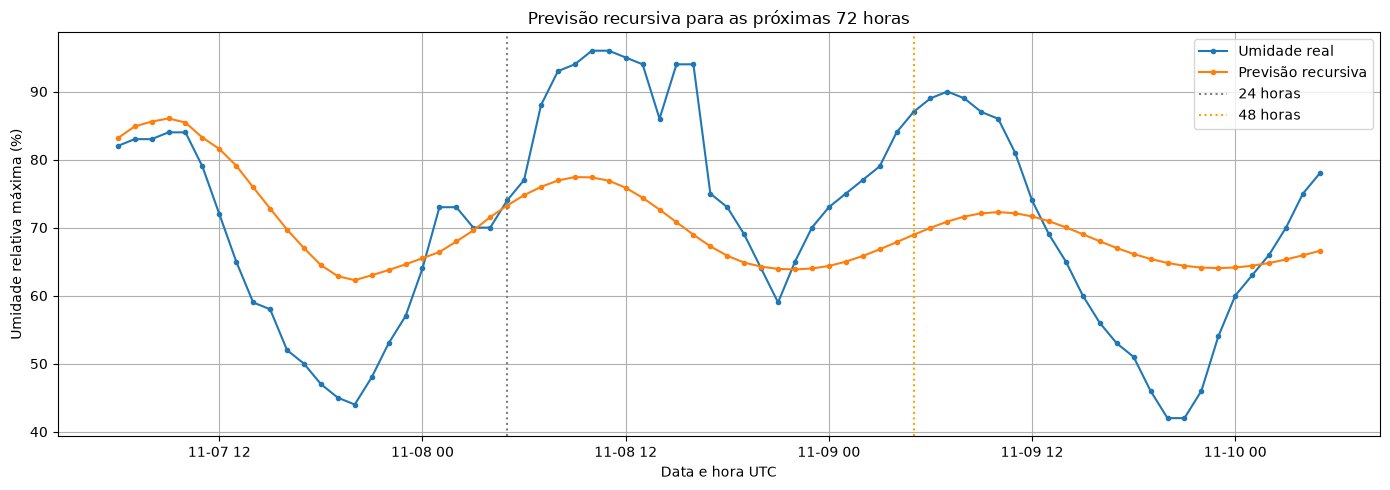

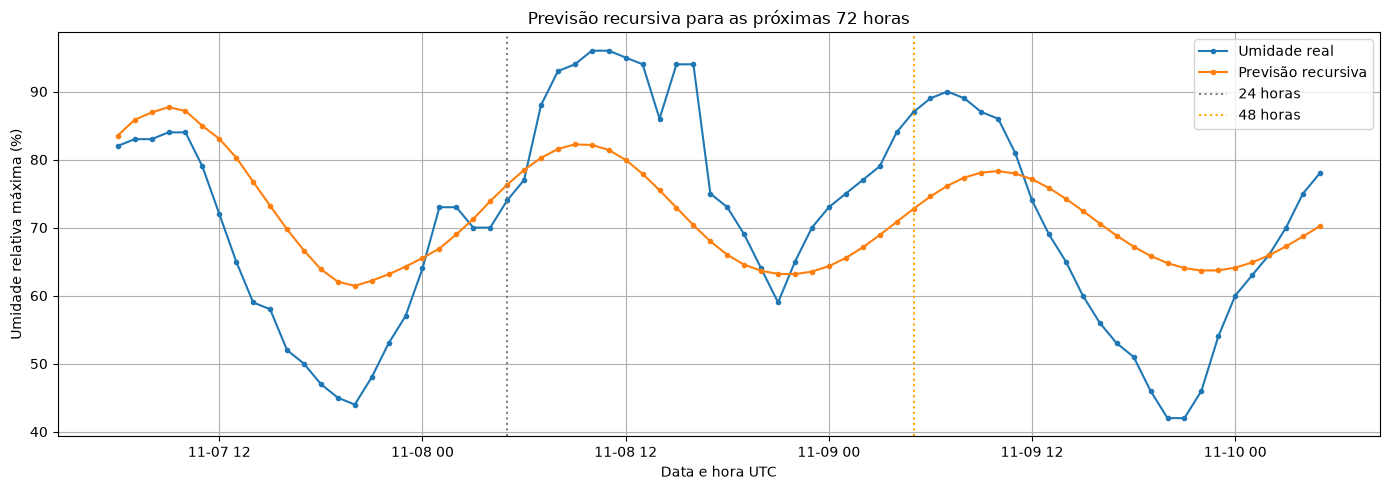

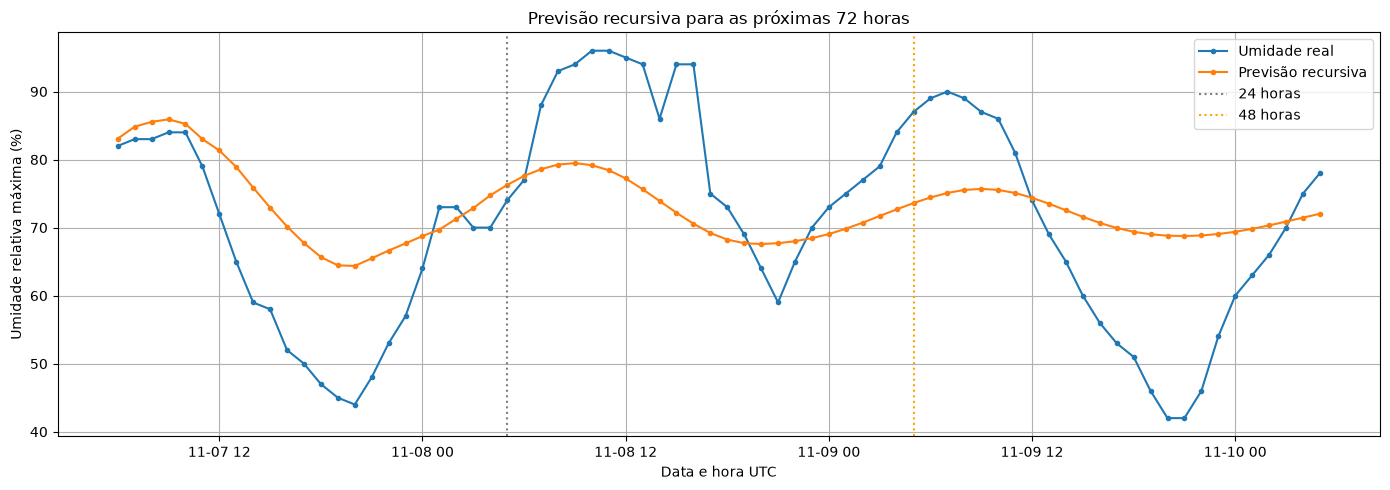

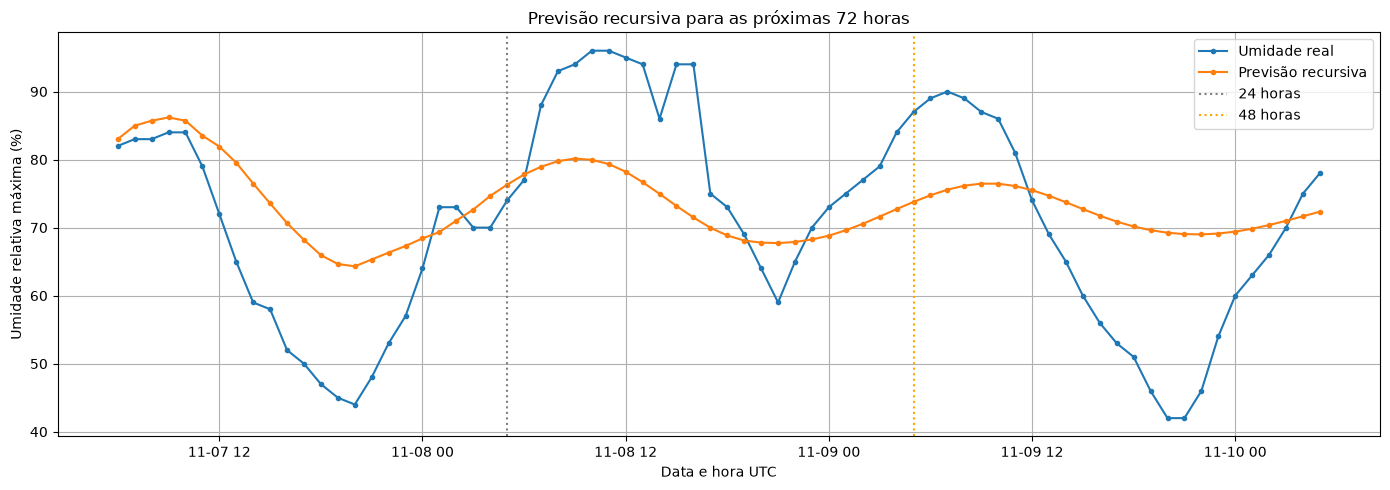

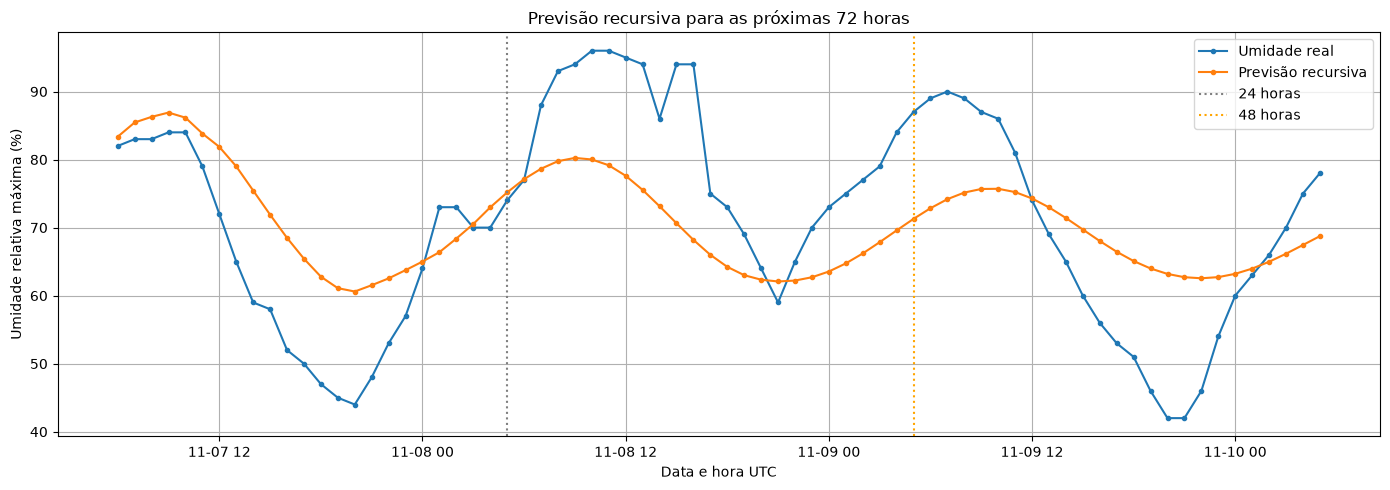


Métricas para o modelo GRU:


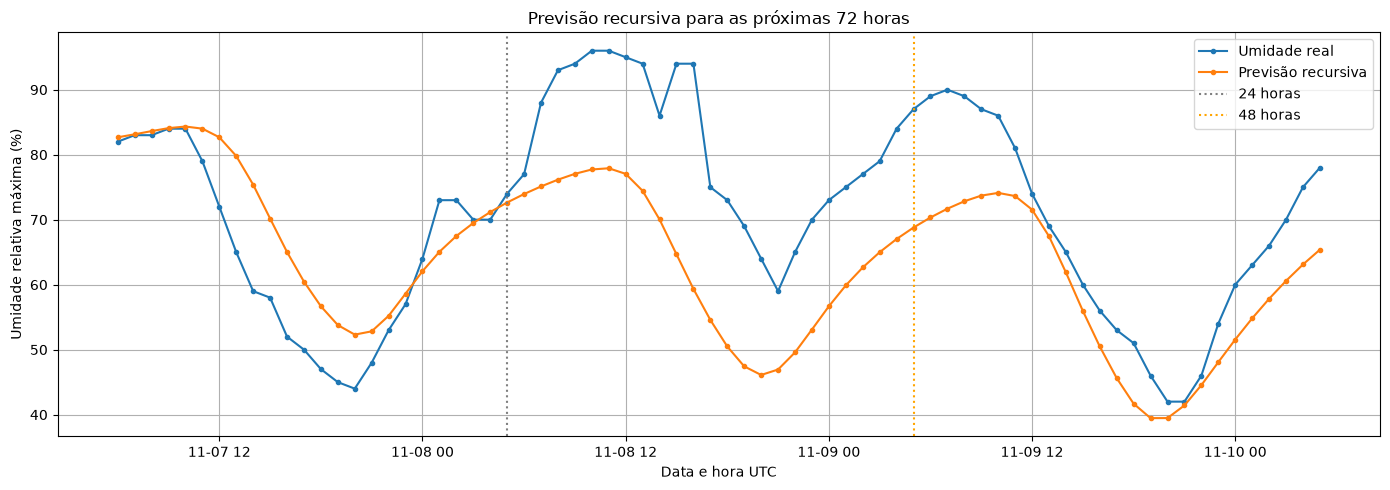

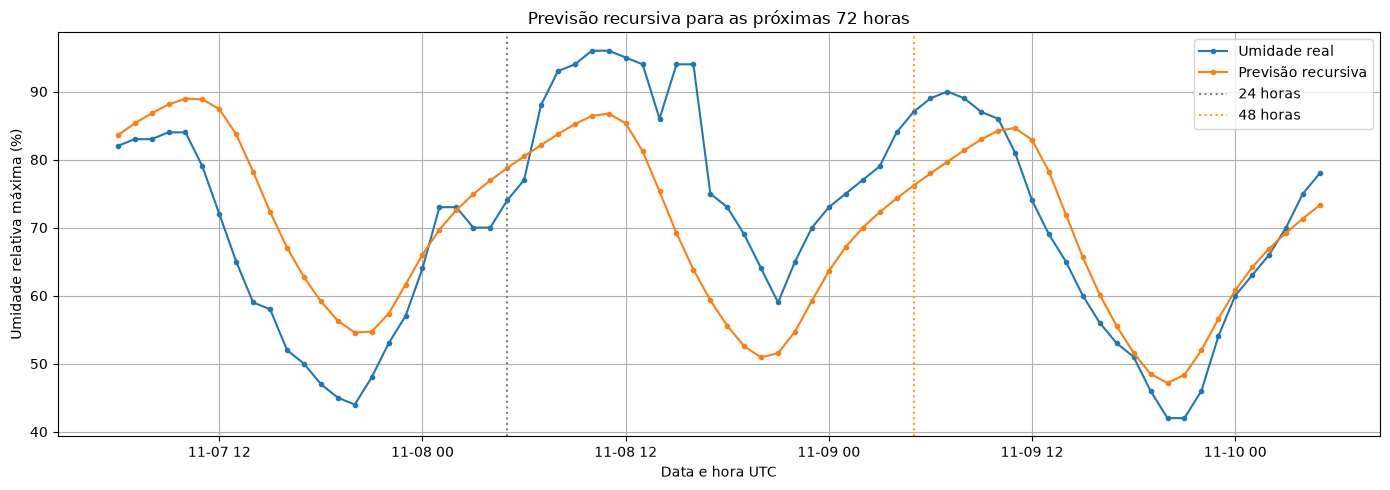

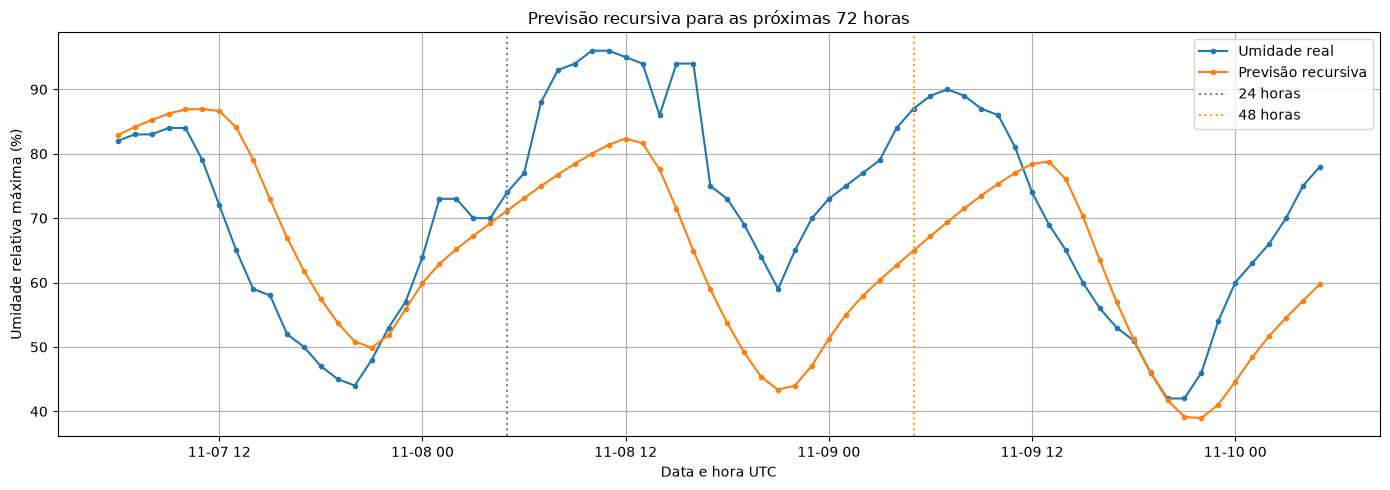

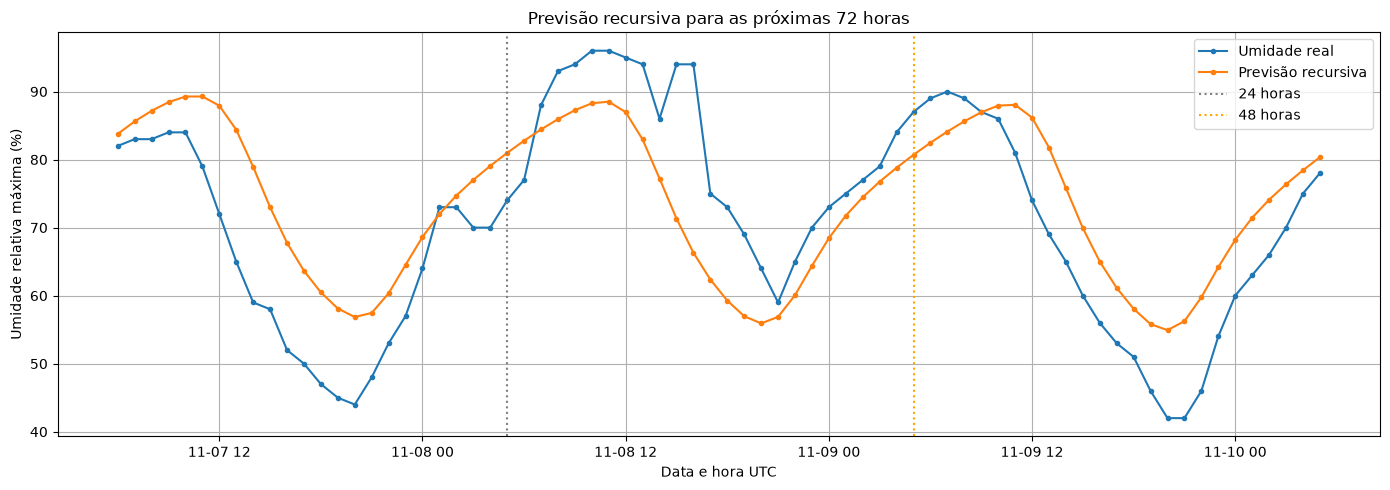

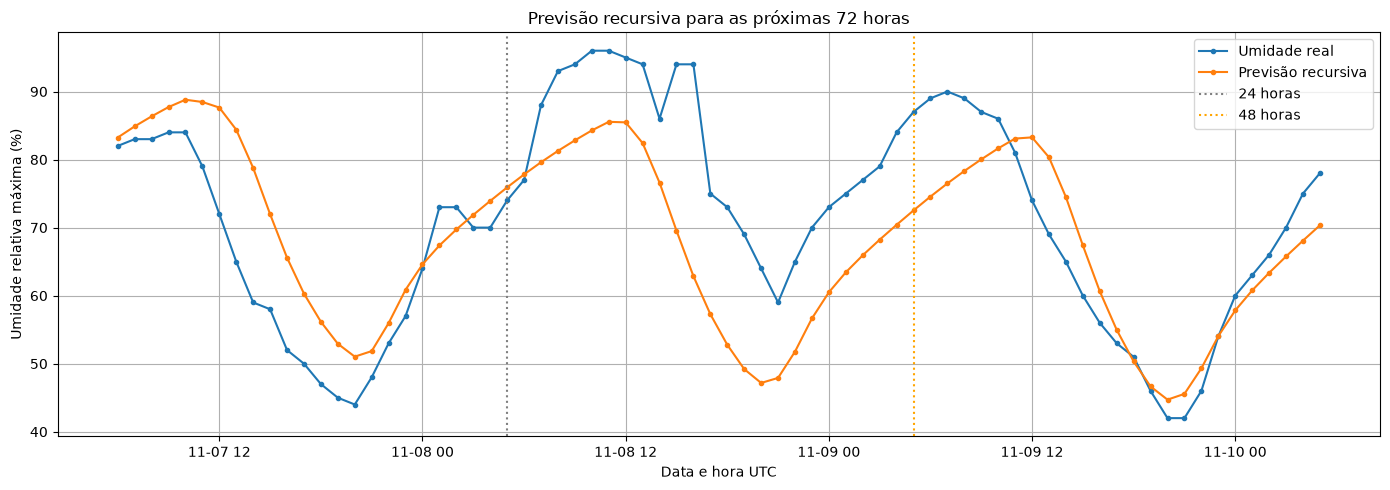

In [17]:
# GERANDO 72 HORAS DE PREVISÃO

historico_teste_norm = serie_normalizada[:indice_inicio_teste]

for model in ["Linear", "GRU"]:
    print(f"\nMétricas para o modelo {model}:")

    for i, (modelo, hist) in enumerate(
        zip(
            modelos_treinados[model],
            historicos[model]
        )
    ):

        pred_72_norm = previsao_recursiva(
            modelo=modelo,
            historico_normalizado=historico_teste_norm,
            tau=tau,
            horizonte=72
        )

        pred_72 = (
            pred_72_norm * desvio_treino
            + media_treino
        )

        real_72 = serie[
            fim_validacao:fim_validacao + 72
        ]

        datas_72 = datas[
            fim_validacao:fim_validacao + 72
        ]

        # GRÁFICO 72 HORAS

        plt.figure(figsize=(14, 5))

        plt.plot(
            datas_72,
            real_72,
            marker="o",
            markersize=3,
            label="Umidade real"
        )

        plt.plot(
            datas_72,
            pred_72,
            marker="o",
            markersize=3,
            label="Previsão recursiva"
        )

        plt.axvline(
            datas_72[23],
            color="gray",
            linestyle=":",
            label="24 horas"
        )

        plt.axvline(
            datas_72[47],
            color="orange",
            linestyle=":",
            label="48 horas"
        )

        plt.xlabel("Data e hora UTC")
        plt.ylabel("Umidade relativa máxima (%)")
        plt.title("Previsão recursiva para as próximas 72 horas")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

### 5.2.1. Como comparar o desempenho dentro das primeiras 12h, 24h, 36h, 48h, 60h e 72h

Isso mede a qualidade da trajetória completa até cada horizonte.

In [18]:
for horizonte in [12, 24, 36, 48, 60, 72]:
    mae_h, rmse_h = calcular_metricas(
        real_72[:horizonte],
        pred_72[:horizonte]
    )

    print(
        f"Horizonte acumulado de {horizonte:02d} horas | "
        f"MAE = {mae_h:.3f} | "
        f"RMSE = {rmse_h:.3f}"
    )

Horizonte acumulado de 12 horas | MAE = 9.756 | RMSE = 11.688
Horizonte acumulado de 24 horas | MAE = 7.045 | RMSE = 8.989
Horizonte acumulado de 36 horas | MAE = 9.087 | RMSE = 11.442
Horizonte acumulado de 48 horas | MAE = 10.326 | RMSE = 12.244
Horizonte acumulado de 60 horas | MAE = 9.863 | RMSE = 11.660
Horizonte acumulado de 72 horas | MAE = 8.731 | RMSE = 10.756


# 6. Avaliação de múltiplas origens em várias janelas de 12h, 24h, 36h, 48h, 60h e 72h

## 6.1. Baseline sazonal 

In [19]:
def previsao_sazonal(
    historico_original,
    horizonte,
    periodo=24
):
    padrao = np.asarray(
        historico_original[-periodo:],
        dtype=np.float32
    )

    repeticoes = int(
        np.ceil(horizonte / periodo)
    )

    return np.tile(
        padrao,
        repeticoes
    )[:horizonte]

### 6.1.1. Avaliação do baseline com as mesmas origens

In [20]:
def avaliar_baseline_sazonal(
    serie_original,
    indice_inicio_avaliacao,
    indice_fim_avaliacao,
    horizontes=(12, 24, 36, 48, 60, 72),
    passo_origem=12,
    periodo=24
):
    horizonte_maximo = max(horizontes)

    resultados = {
        h: {
            "residuos": [],
            "mae_por_origem": [],
            "rmse_por_origem": [],
            "origens": []
        }
        for h in horizontes
    }

    ultimo_inicio = (
        indice_fim_avaliacao
        - horizonte_maximo
    )

    for origem in range(
        indice_inicio_avaliacao,
        ultimo_inicio + 1,
        passo_origem
    ):
        historico = serie_original[:origem]

        pred = previsao_sazonal(
            historico_original=historico,
            horizonte=horizonte_maximo,
            periodo=periodo
        )

        real = serie_original[
            origem:origem + horizonte_maximo
        ]

        for h in horizontes:
            residuos_h = (
                real[:h] - pred[:h]
            )

            resultados[h]["residuos"].extend(
                residuos_h.tolist()
            )

            resultados[h][
                "mae_por_origem"
            ].append(
                np.mean(np.abs(residuos_h))
            )

            resultados[h][
                "rmse_por_origem"
            ].append(
                np.sqrt(
                    np.mean(residuos_h ** 2)
                )
            )

            resultados[h]["origens"].append(
                origem
            )

    return resultados

In [21]:
resultados_baseline_teste = (
    avaliar_baseline_sazonal(
        serie_original=serie,
        indice_inicio_avaliacao=fim_validacao,
        indice_fim_avaliacao=len(serie),
        horizontes=(12, 24, 36, 48, 60, 72),
        passo_origem=12,
        periodo=24
    )
)

## 6.2. Modelos 

### 6.1.1. Avaliação dod modelos com as mesmas origens

In [22]:
def avaliar_horizontes_acumulados(
    modelo,
    serie_normalizada,
    serie_original,
    indice_inicio_avaliacao,
    indice_fim_avaliacao,
    tau,
    media_treino,
    desvio_treino,
    horizontes=(12, 24, 48, 72),
    passo_origem=12
):
    horizonte_maximo = max(horizontes)

    resultados = {
        h: {
            "residuos": [],
            "mae_por_origem": [],
            "rmse_por_origem": [],
            "origens": []
        }
        for h in horizontes
    }

    ultimo_inicio = (
        indice_fim_avaliacao
        - horizonte_maximo
    )

    for origem in range(
        indice_inicio_avaliacao,
        ultimo_inicio + 1,
        passo_origem
    ):
        historico = serie_normalizada[:origem]

        pred_norm = previsao_recursiva(
            modelo=modelo,
            historico_normalizado=historico,
            tau=tau,
            horizonte=horizonte_maximo
        )

        pred = (
            pred_norm * desvio_treino
            + media_treino
        )

        real = serie_original[
            origem:origem + horizonte_maximo
        ]

        for h in horizontes:
            residuos_h = (
                real[:h] - pred[:h]
            )

            resultados[h]["residuos"].extend(
                residuos_h.tolist()
            )

            resultados[h][
                "mae_por_origem"
            ].append(
                np.mean(np.abs(residuos_h))
            )

            resultados[h][
                "rmse_por_origem"
            ].append(
                np.sqrt(
                    np.mean(residuos_h ** 2)
                )
            )

            resultados[h]["origens"].append(
                origem
            )

    return resultados

## 6.1. Como resumir os resultados

Há duas formas legítimas de agregar os resultados.



In [25]:
def resumir_resultados(resultados):
    resumo = []

    for horizonte, dados in resultados.items():
        residuos = np.asarray(
            dados["residuos"],
            dtype=float
        )

        mae = np.mean(np.abs(residuos))

        rmse = np.sqrt(
            np.mean(residuos ** 2)
        )

        mediana_abs = np.median(
            np.abs(residuos)
        )

        resumo.append({
            "horizonte": horizonte,
            "mae": mae,
            "rmse": rmse,
            "mediana_absoluta": mediana_abs,
            "n_origens": len(
                dados["mae_por_origem"]
            ),
            "n_previsoes": len(residuos)
        })

    return pd.DataFrame(resumo)

In [26]:
resultados_modelos_teste = {
    "Linear": [],
    "GRU": []
}

for nome_modelo in ["Linear", "GRU"]:
    for modelo in modelos_treinados[nome_modelo]:

        resultado = avaliar_horizontes_acumulados(
            modelo=modelo,
            serie_normalizada=serie_normalizada,
            serie_original=serie,
            indice_inicio_avaliacao=fim_validacao,
            indice_fim_avaliacao=len(serie),
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            horizontes=(12, 24, 36, 48, 60, 72),
            passo_origem=12
        )

        resultados_modelos_teste[
            nome_modelo
        ].append(resultado)

In [27]:
registros_sementes = []

for nome_modelo in ["Linear", "GRU"]:
    for semente, modelo in zip(
        SEMENTES,
        modelos_treinados[nome_modelo]
    ):
        resultados = avaliar_horizontes_acumulados(
            modelo=modelo,
            serie_normalizada=serie_normalizada,
            serie_original=serie,
            indice_inicio_avaliacao=fim_validacao,
            indice_fim_avaliacao=len(serie),
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            horizontes=(12, 24, 36, 48, 60, 72),
            passo_origem=12
        )

        resumo = resumir_resultados(resultados)

        resumo["modelo"] = nome_modelo
        resumo["semente"] = semente

        registros_sementes.append(resumo)

resultados_execucoes = pd.concat(
    registros_sementes,
    ignore_index=True
)

### 6.1.1. Forma A: erro global de todas as previsões

Junta todos os resíduos de todas as origens:

In [28]:
resumo_final = (
    resultados_execucoes
    .groupby(["modelo", "horizonte"])
    .agg(
        mae_media=("mae", "mean"),
        mae_dp=("mae", "std"),
        rmse_media=("rmse", "mean"),
        rmse_dp=("rmse", "std"),
        execucoes=("semente", "nunique")
    )
    .reset_index()
)

print(resumo_final)

    modelo  horizonte  mae_media    mae_dp  rmse_media   rmse_dp  execucoes
0      GRU         12   9.060943  0.142838   12.353511  0.204060          5
1      GRU         24  10.188076  0.258165   13.856812  0.264342          5
2      GRU         36  11.370287  0.318643   15.425394  0.415512          5
3      GRU         48  12.239507  0.482099   16.566081  0.603697          5
4      GRU         60  12.990071  0.598559   17.507003  0.806499          5
5      GRU         72  13.600495  0.772461   18.291963  1.034432          5
6   Linear         12   7.877323  0.088649   11.073336  0.180993          5
7   Linear         24   9.408616  0.087513   12.733673  0.081814          5
8   Linear         36  10.570099  0.102787   13.988213  0.099903          5
9   Linear         48  11.434483  0.146728   14.860214  0.135956          5
10  Linear         60  12.118803  0.172783   15.511574  0.167673          5
11  Linear         72  12.656380  0.199552   15.996876  0.194103          5


# 7. Teste de hipótese entre Linear e GRU

### Hipóteses
$$
H_0: \text{não há diferença de desempenho entre os modelos}
$$
$$
H_1: \text{há diferença de desempenho entre os modelos}
$$

In [29]:
def obter_mae_medio_por_origem(
    lista_resultados,
    horizonte
):
    matriz = np.vstack([
        resultado[horizonte]["mae_por_origem"]
        for resultado in lista_resultados
    ])

    return {
        "media": matriz.mean(axis=0),
        "desvio_padrao": matriz.std(
            axis=0,
            ddof=1
        ),
        "matriz": matriz
    }

In [30]:
mae_linear = obter_mae_medio_por_origem(
    resultados_modelos_teste["Linear"],
    horizonte=72
)

mae_gru = obter_mae_medio_por_origem(
    resultados_modelos_teste["GRU"],
    horizonte=72
)

In [31]:
mae_linear_por_origem = mae_linear["media"]
mae_gru_por_origem = mae_gru["media"]

## 7.1. Teste t pareado

In [33]:
from scipy.stats import ttest_rel

estatistica, p_valor = ttest_rel(
    mae_linear_por_origem,
    mae_gru_por_origem
)

## 7.2. Wilcoxon pareado

In [34]:
from scipy.stats import wilcoxon

estatistica, p_valor = wilcoxon(
    mae_linear_por_origem,
    mae_gru_por_origem
)

# 8. Gráficos

## 8.1. MAE médio por horizonte

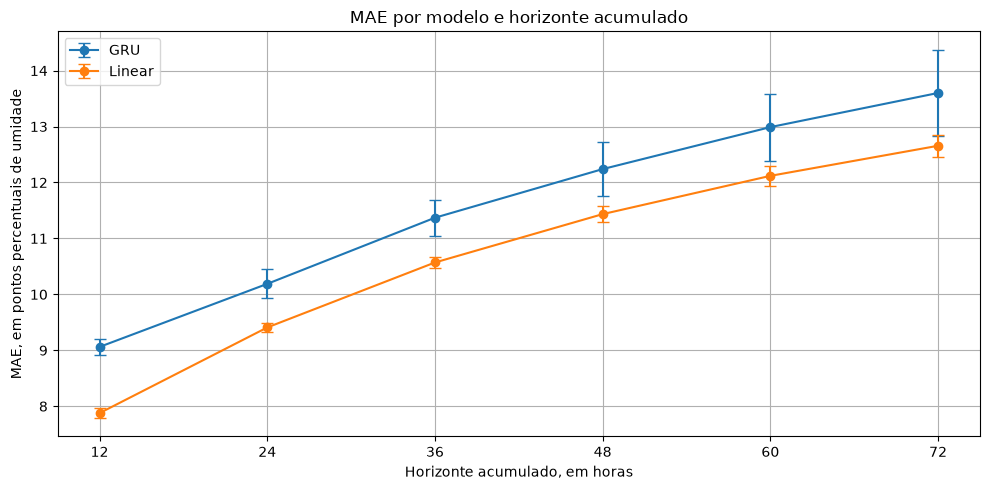

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))

for modelo, grupo in resumo_final.groupby("modelo"):
    ax.errorbar(
        grupo["horizonte"],
        grupo["mae_media"],
        yerr=grupo["mae_dp"],
        marker="o",
        capsize=4,
        label=modelo
    )

ax.set_xlabel("Horizonte acumulado, em horas")
ax.set_ylabel(
    "MAE, em pontos percentuais de umidade"
)
ax.set_title(
    "MAE por modelo e horizonte acumulado"
)
ax.set_xticks([12, 24, 36, 48, 60, 72])
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 8.2 RMSE médio por horizonte

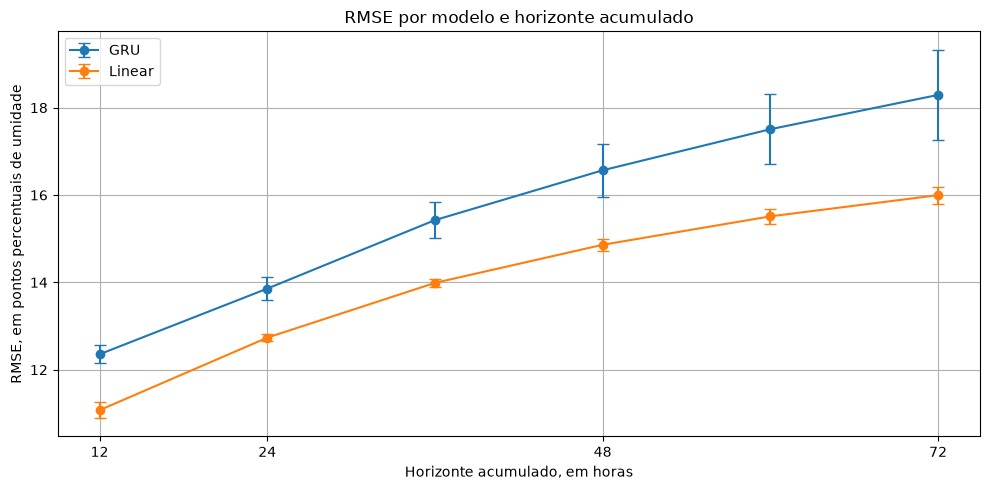

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

for modelo, grupo in resumo_final.groupby("modelo"):
    ax.errorbar(
        grupo["horizonte"],
        grupo["rmse_media"],
        yerr=grupo["rmse_dp"],
        marker="o",
        capsize=4,
        label=modelo
    )

ax.set_xlabel("Horizonte acumulado, em horas")
ax.set_ylabel(
    "RMSE, em pontos percentuais de umidade"
)
ax.set_title(
    "RMSE por modelo e horizonte acumulado"
)
ax.set_xticks([12, 24, 48, 72])
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 8.3. Boxplot do MAE por origem

In [73]:
dados_boxplot = []

resultados_linear = (
    resultados_execucoes[
        resultados_execucoes["modelo"] == "Linear"
    ]
    .groupby("horizonte")
    .agg(
        mae_por_origem=("mae", lambda x: list(x))
    )
    .to_dict(orient="index")
)

resultados_gru = (
    resultados_execucoes[
        resultados_execucoes["modelo"] == "GRU"
    ]
    .groupby("horizonte")
    .agg(
        mae_por_origem=("mae", lambda x: list(x))
    )
    .to_dict(orient="index")
)

for nome, resultados in [
    ("Linear", resultados_linear),
    ("GRU", resultados_gru),
    ("Baseline", resultados_baseline_teste)
]:
    for horizonte in [12, 24, 48, 72]:
        for valor in resultados[
            horizonte
        ]["mae_por_origem"]:
            dados_boxplot.append({
                "modelo": nome,
                "horizonte": horizonte,
                "mae": valor
            })

df_boxplot = pd.DataFrame(dados_boxplot)

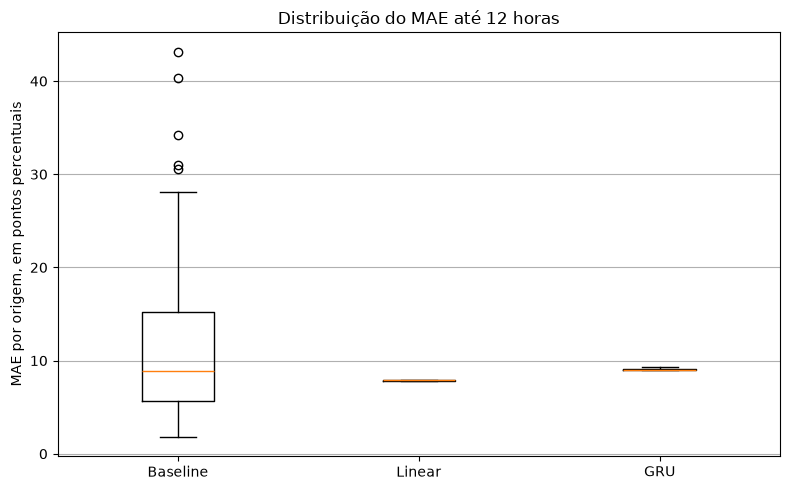

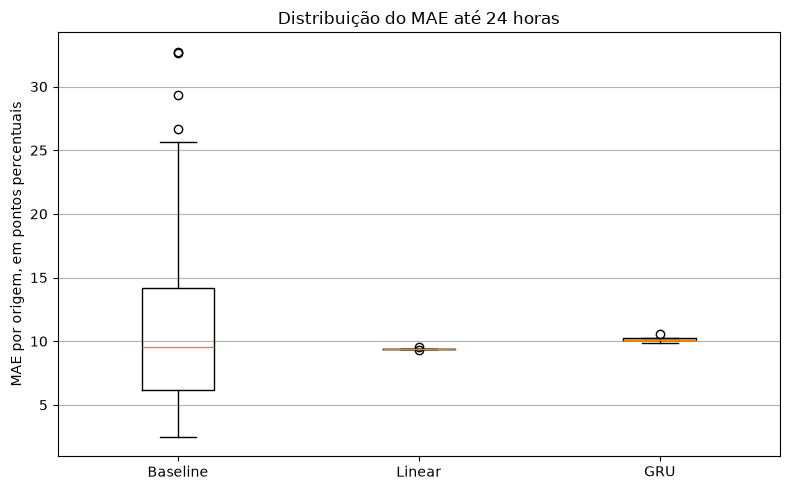

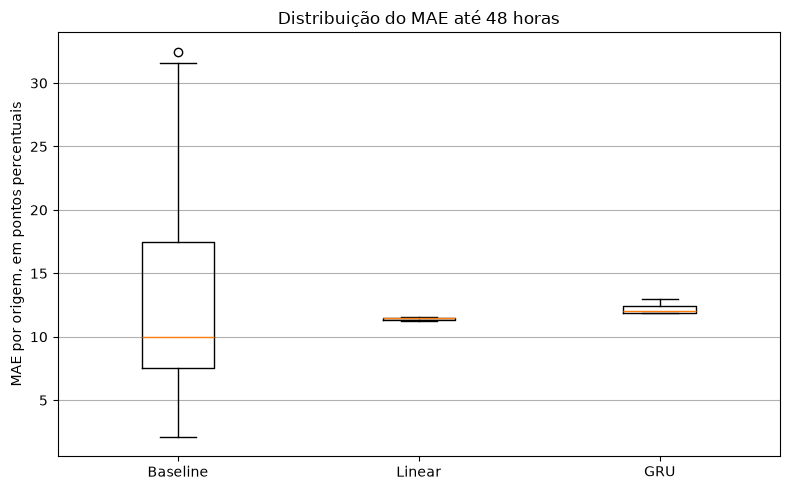

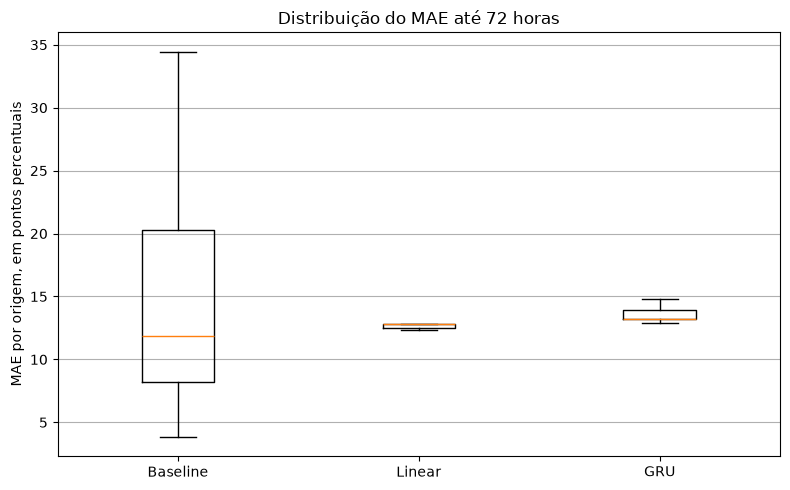

In [74]:
for horizonte in [12, 24, 48, 72]:
    dados_h = df_boxplot[
        df_boxplot["horizonte"] == horizonte
    ]

    grupos = [
        dados_h.loc[
            dados_h["modelo"] == modelo,
            "mae"
        ].to_numpy()
        for modelo in ["Baseline", "Linear", "GRU"]
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        grupos,
        tick_labels=["Baseline", "Linear", "GRU"]
    )

    plt.ylabel(
        "MAE por origem, em pontos percentuais"
    )

    plt.title(
        f"Distribuição do MAE até {horizonte} horas"
    )

    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

12 h | Baseline: 104 | Linear: 104 | GRU: 104


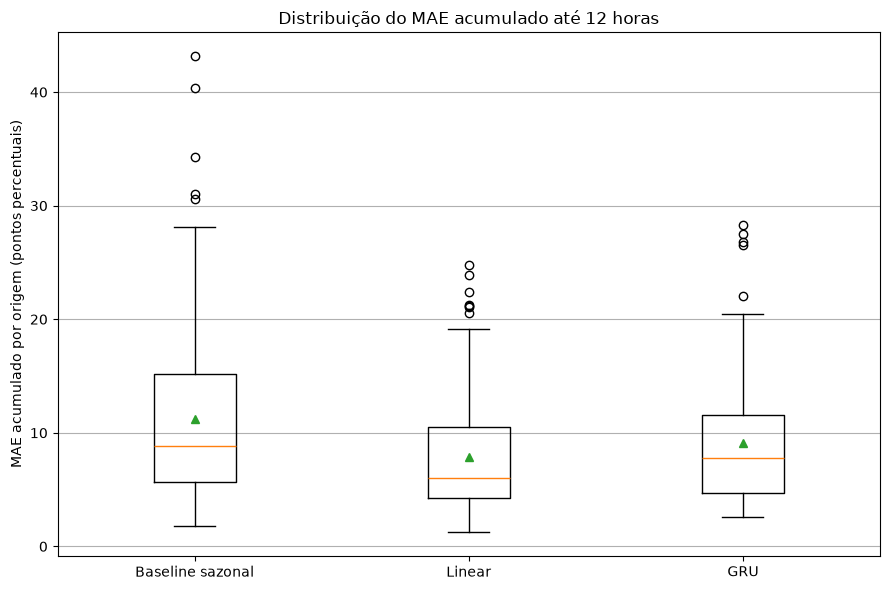

24 h | Baseline: 104 | Linear: 104 | GRU: 104


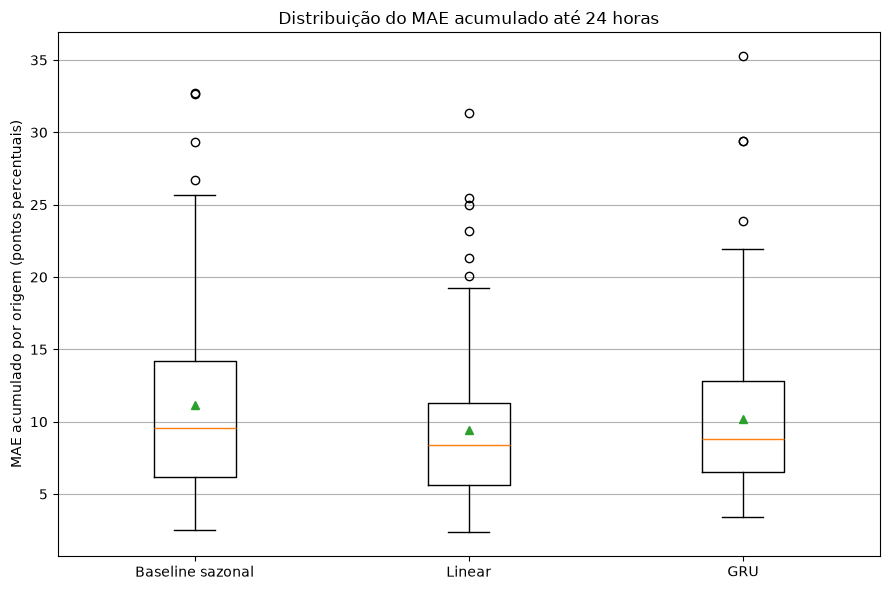

48 h | Baseline: 104 | Linear: 104 | GRU: 104


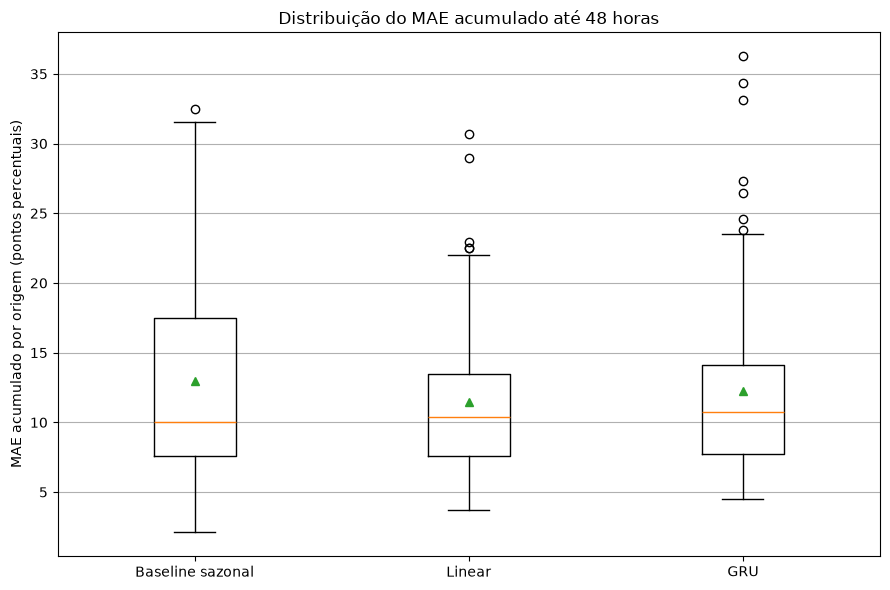

72 h | Baseline: 104 | Linear: 104 | GRU: 104


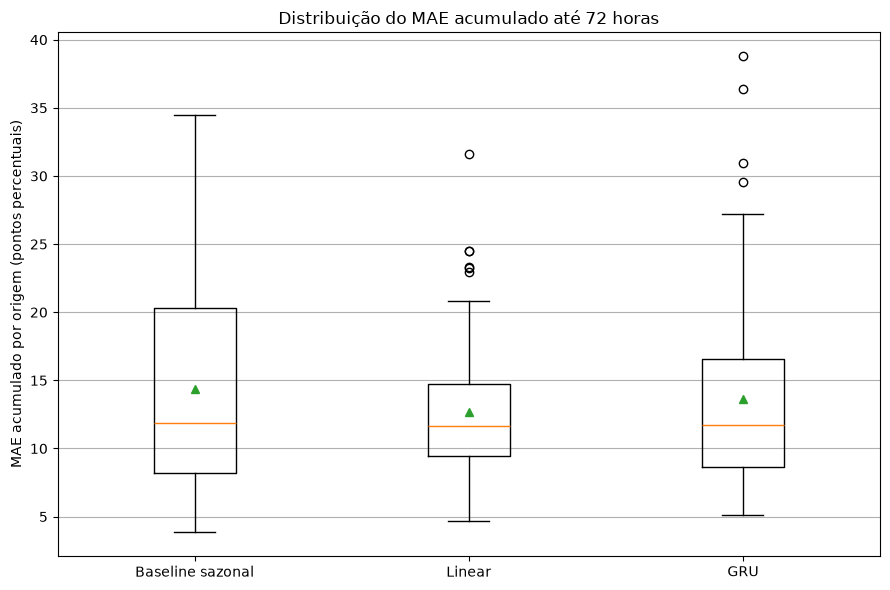

In [35]:
HORIZONTES = (12, 24, 36, 48, 60, 72)

for horizonte in [12, 24, 48, 72]:

    mae_linear_h = obter_mae_medio_por_origem(
        resultados_modelos_teste["Linear"],
        horizonte
    )["media"]

    mae_gru_h = obter_mae_medio_por_origem(
        resultados_modelos_teste["GRU"],
        horizonte
    )["media"]

    mae_baseline_h = np.asarray(
        resultados_baseline_teste[
            horizonte
        ]["mae_por_origem"],
        dtype=float
    )

    print(
        f"{horizonte} h | "
        f"Baseline: {len(mae_baseline_h)} | "
        f"Linear: {len(mae_linear_h)} | "
        f"GRU: {len(mae_gru_h)}"
    )

    assert (
        len(mae_baseline_h)
        == len(mae_linear_h)
        == len(mae_gru_h)
    )

    plt.figure(figsize=(9, 6))

    plt.boxplot(
        [
            mae_baseline_h,
            mae_linear_h,
            mae_gru_h
        ],
        tick_labels=[
            "Baseline sazonal",
            "Linear",
            "GRU"
        ],
        showmeans=True
    )

    plt.ylabel(
        "MAE acumulado por origem "
        "(pontos percentuais)"
    )

    plt.title(
        f"Distribuição do MAE acumulado "
        f"até {horizonte} horas"
    )

    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

## 8.4. Trajetória comparativa de 72 horas

In [1]:
resultados_execucoes[
        (resultados_execucoes["modelo"] == "Linear")
        & (resultados_execucoes["horizonte"] == 72)
    ]

NameError: name 'resultados_execucoes' is not defined

In [78]:
resultados_execucoes[
        (resultados_execucoes["modelo"] == "GRU")
        & (resultados_execucoes["horizonte"] == 72)
    ]

,horizonte,mae,rmse,mediana_absoluta,n_origens,n_previsoes,modelo,semente
35,72,14.792895,19.828600,11.262012,104,7488,GRU,10
41,72,13.176177,17.717404,9.509375,104,7488,GRU,20
47,72,13.928399,18.781668,10.126431,104,7488,GRU,30
53,72,13.248465,17.950246,9.802841,104,7488,GRU,40
59,72,12.856538,17.181899,9.464256,104,7488,GRU,50


In [80]:
resultados_execucoes[
        (resultados_execucoes["modelo"] == "Baseline")
        & (resultados_execucoes["horizonte"] == 72)
    ]

,horizonte,mae,rmse,mediana_absoluta,n_origens,n_previsoes,modelo,semente


In [ ]:
datas_origem = datas_teste[:-72]
real_origem = serie_teste[:-72]
pred_linear_origem = (
    resultados_execucoes[
        (resultados_execucoes["modelo"] == "Linear")
        & (resultados_execucoes["horizonte"] == 72)
    ]
    .sort_values("semente")["mae"]
    .explode()
    .to_numpy(dtype=np.float32)
)
pred_gru_origem = (
    resultados_execucoes[
        (resultados_execucoes["modelo"] == "GRU")
        & (resultados_execucoes["horizonte"] == 72)
    ]
    .sort_values("semente")["mae"]
    .explode()
    .to_numpy(dtype=np.float32)
)
pred_baseline_origem = (
    resultados_execucoes[
        (resultados_execucoes["modelo"] == "Baseline")
        & (resultados_execucoes["horizonte"] == 72)
    ]
    .sort_values("semente")["mae"]
    .explode()
    .to_numpy(dtype=np.float32)
)



ValueError: x and y must have same first dimension, but have shapes (1242,) and (5,)

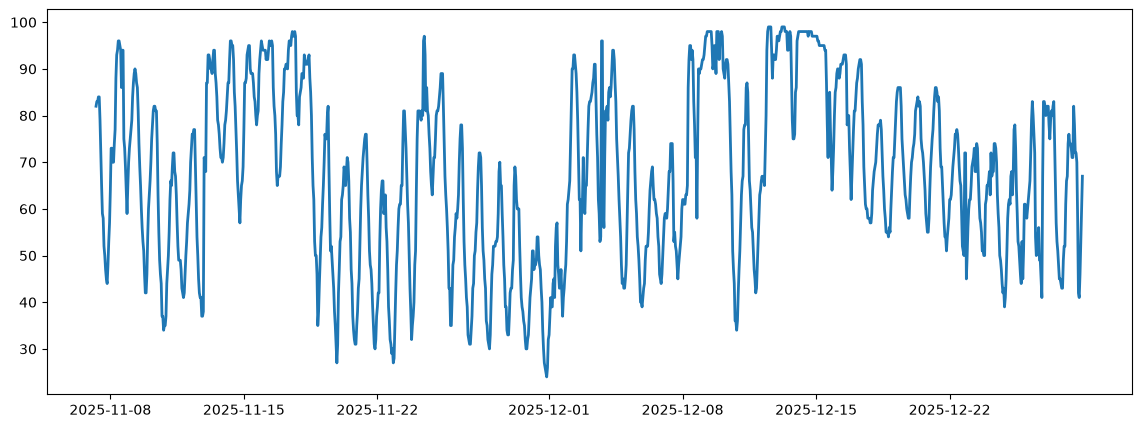

In [85]:
plt.figure(figsize=(14, 5))

plt.plot(
    datas_origem,
    real_origem,
    linewidth=2,
    label="Real"
)

plt.plot(
    datas_origem,
    pred_linear_origem,
    label="Linear"
)

plt.plot(
    datas_origem,
    pred_gru_origem,
    label="GRU"
)

plt.plot(
    datas_origem,
    pred_baseline_origem,
    linestyle=":",
    label="Baseline sazonal"
)

plt.axvline(
    datas_origem[23],
    color="gray",
    linestyle=":"
)

plt.axvline(
    datas_origem[47],
    color="gray",
    linestyle=":"
)

plt.xlabel("Data e hora UTC")
plt.ylabel("Umidade relativa máxima (%)")
plt.title(
    "Comparação das trajetórias previstas em 72 horas"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
horizonte_grafico = 72
origem_grafico = fim_validacao

In [37]:
datas_origem = datas[
    origem_grafico:
    origem_grafico + horizonte_grafico
]

real_origem = serie[
    origem_grafico:
    origem_grafico + horizonte_grafico
]

In [38]:
historico_normalizado_origem = (
    serie_normalizada[:origem_grafico]
)

historico_original_origem = (
    serie[:origem_grafico]
)

In [39]:
modelo_linear_grafico = (
    modelos_treinados["Linear"][0]
)

modelo_gru_grafico = (
    modelos_treinados["GRU"][0]
)

In [40]:
pred_linear_norm = previsao_recursiva(
    modelo=modelo_linear_grafico,
    historico_normalizado=historico_normalizado_origem,
    tau=tau,
    horizonte=horizonte_grafico
)

pred_linear_origem = (
    pred_linear_norm * desvio_treino
    + media_treino
)

In [41]:
pred_gru_norm = previsao_recursiva(
    modelo=modelo_gru_grafico,
    historico_normalizado=historico_normalizado_origem,
    tau=tau,
    horizonte=horizonte_grafico
)

pred_gru_origem = (
    pred_gru_norm * desvio_treino
    + media_treino
)

In [42]:
pred_baseline_origem = previsao_sazonal(
    historico_original=historico_original_origem,
    horizonte=horizonte_grafico,
    periodo=24
)

In [43]:
assert len(datas_origem) == 72
assert len(real_origem) == 72
assert len(pred_linear_origem) == 72
assert len(pred_gru_origem) == 72
assert len(pred_baseline_origem) == 72

In [44]:
previsoes_linear_sementes = []

for modelo in modelos_treinados["Linear"]:

    pred_norm = previsao_recursiva(
        modelo=modelo,
        historico_normalizado=historico_normalizado_origem,
        tau=tau,
        horizonte=horizonte_grafico
    )

    pred = (
        pred_norm * desvio_treino
        + media_treino
    )

    previsoes_linear_sementes.append(pred)

previsoes_linear_sementes = np.vstack(
    previsoes_linear_sementes
)

pred_linear_origem = (
    previsoes_linear_sementes.mean(axis=0)
)

dp_linear_origem = (
    previsoes_linear_sementes.std(
        axis=0,
        ddof=1
    )
)

In [45]:
previsoes_gru_sementes = []

for modelo in modelos_treinados["GRU"]:

    pred_norm = previsao_recursiva(
        modelo=modelo,
        historico_normalizado=historico_normalizado_origem,
        tau=tau,
        horizonte=horizonte_grafico
    )

    pred = (
        pred_norm * desvio_treino
        + media_treino
    )

    previsoes_gru_sementes.append(pred)

previsoes_gru_sementes = np.vstack(
    previsoes_gru_sementes
)

pred_gru_origem = (
    previsoes_gru_sementes.mean(axis=0)
)

dp_gru_origem = (
    previsoes_gru_sementes.std(
        axis=0,
        ddof=1
    )
)

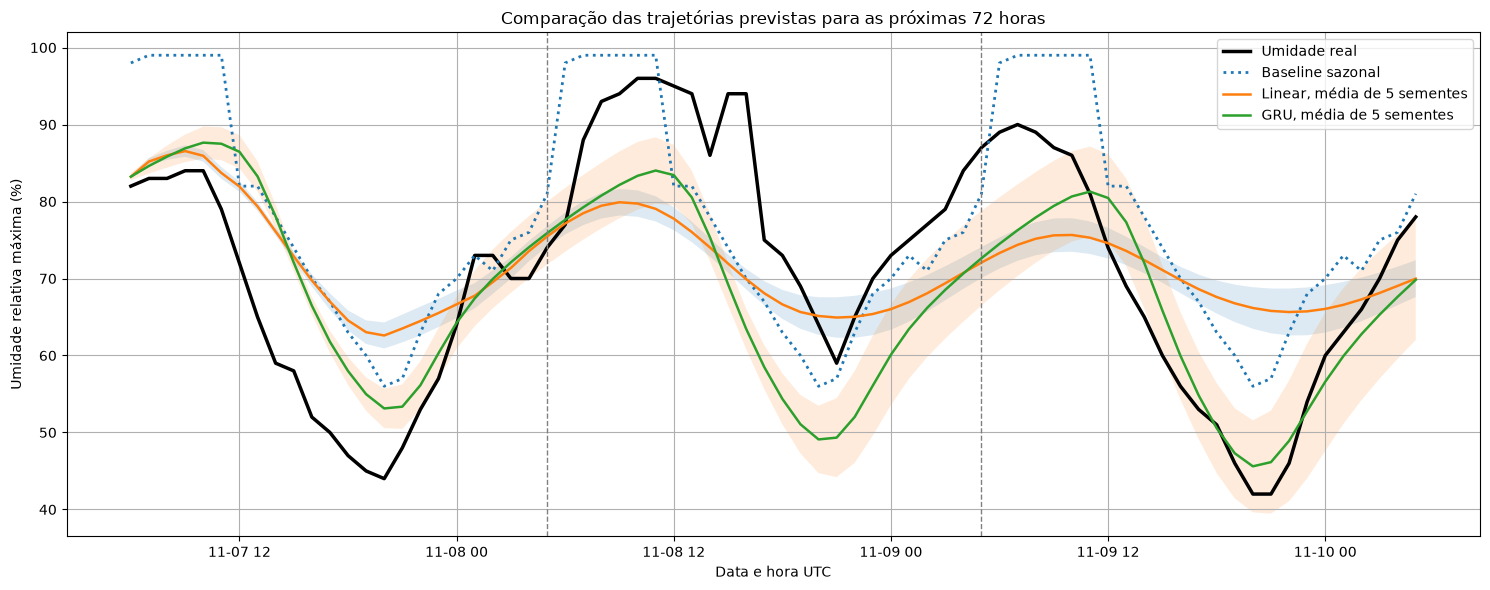

In [46]:
plt.figure(figsize=(15, 6))

plt.plot(
    datas_origem,
    real_origem,
    color="black",
    linewidth=2.5,
    label="Umidade real"
)

plt.plot(
    datas_origem,
    pred_baseline_origem,
    linestyle=":",
    linewidth=2,
    label="Baseline sazonal"
)

plt.plot(
    datas_origem,
    pred_linear_origem,
    linewidth=1.8,
    label="Linear, média de 5 sementes"
)

plt.fill_between(
    datas_origem,
    pred_linear_origem - dp_linear_origem,
    pred_linear_origem + dp_linear_origem,
    alpha=0.15
)

plt.plot(
    datas_origem,
    pred_gru_origem,
    linewidth=1.8,
    label="GRU, média de 5 sementes"
)

plt.fill_between(
    datas_origem,
    pred_gru_origem - dp_gru_origem,
    pred_gru_origem + dp_gru_origem,
    alpha=0.15
)

plt.axvline(
    datas_origem[23],
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    datas_origem[47],
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Data e hora UTC")
plt.ylabel("Umidade relativa máxima (%)")

plt.title(
    "Comparação das trajetórias previstas "
    "para as próximas 72 horas"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
resultados_hipotese = {
    "Linear": [],
    "GRU": []
}

for nome_modelo in ["Linear", "GRU"]:
    for modelo in modelos_treinados[nome_modelo]:
        resultado = avaliar_horizontes_acumulados(
            modelo=modelo,
            serie_normalizada=serie_normalizada,
            serie_original=serie,
            indice_inicio_avaliacao=fim_validacao,
            indice_fim_avaliacao=len(serie),
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            horizontes=(12, 24, 36, 48, 60, 72),
            passo_origem=12
        )

        resultados_hipotese[nome_modelo].append(
            resultado
        )

In [53]:
maes_linear_matriz = np.vstack([
    resultado[72]["mae_por_origem"]
    for resultado in resultados_hipotese["Linear"]
])

maes_gru_matriz = np.vstack([
    resultado[72]["mae_por_origem"]
    for resultado in resultados_hipotese["GRU"]
])

print(
    "Matriz Linear:",
    maes_linear_matriz.shape
)

print(
    "Matriz GRU:",
    maes_gru_matriz.shape
)

Matriz Linear: (5, 104)
Matriz GRU: (5, 104)


In [54]:
mae_linear_por_origem = (
    maes_linear_matriz.mean(axis=0)
)

mae_gru_por_origem = (
    maes_gru_matriz.mean(axis=0)
)

In [55]:
origens_linear = np.asarray(
    resultados_hipotese["Linear"][0][72][
        "origens"
    ]
)

origens_gru = np.asarray(
    resultados_hipotese["GRU"][0][72][
        "origens"
    ]
)

assert np.array_equal(
    origens_linear,
    origens_gru
)

assert len(mae_linear_por_origem) == len(
    mae_gru_por_origem
)

print(
    "Número de pares:",
    len(mae_linear_por_origem)
)

Número de pares: 104


In [56]:
diferencas = (
    mae_linear_por_origem
    - mae_gru_por_origem
)

print(
    f"MAE médio Linear: "
    f"{mae_linear_por_origem.mean():.3f}"
)

print(
    f"MAE médio GRU: "
    f"{mae_gru_por_origem.mean():.3f}"
)

print(
    f"Diferença média Linear - GRU: "
    f"{diferencas.mean():.3f}"
)

MAE médio Linear: 12.656
MAE médio GRU: 13.600
Diferença média Linear - GRU: -0.944


In [57]:
from scipy.stats import wilcoxon

estatistica_w, p_valor_w = wilcoxon(
    mae_linear_por_origem,
    mae_gru_por_origem,
    alternative="two-sided"
)

print(
    f"Wilcoxon | "
    f"estatística = {estatistica_w:.4f} | "
    f"p-valor = {p_valor_w:.6f}"
)

Wilcoxon | estatística = 2134.0000 | p-valor = 0.053272


In [58]:
from scipy.stats import ttest_rel

estatistica_t, p_valor_t = ttest_rel(
    mae_linear_por_origem,
    mae_gru_por_origem
)

print(
    f"Teste t pareado | "
    f"t = {estatistica_t:.4f} | "
    f"p-valor = {p_valor_t:.6f}"
)

Teste t pareado | t = -2.6081 | p-valor = 0.010458


In [60]:
diferencas_mae = (
    mae_linear_por_origem
    - mae_gru_por_origem
)

In [61]:
from scipy.stats import shapiro

estatistica_shapiro, p_shapiro = shapiro(
    diferencas_mae
)

print(
    f"Shapiro-Wilk | "
    f"estatística = {estatistica_shapiro:.4f} | "
    f"p-valor = {p_shapiro:.6f}"
)

Shapiro-Wilk | estatística = 0.9619 | p-valor = 0.004402


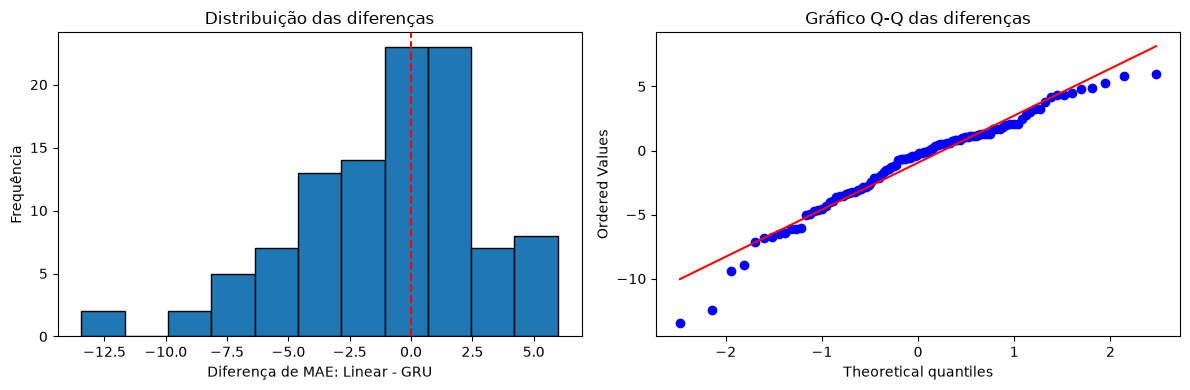

In [62]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    diferencas_mae,
    bins="auto",
    edgecolor="black"
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xlabel("Diferença de MAE: Linear - GRU")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das diferenças")

stats.probplot(
    diferencas_mae,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Gráfico Q-Q das diferenças")

plt.tight_layout()
plt.show()

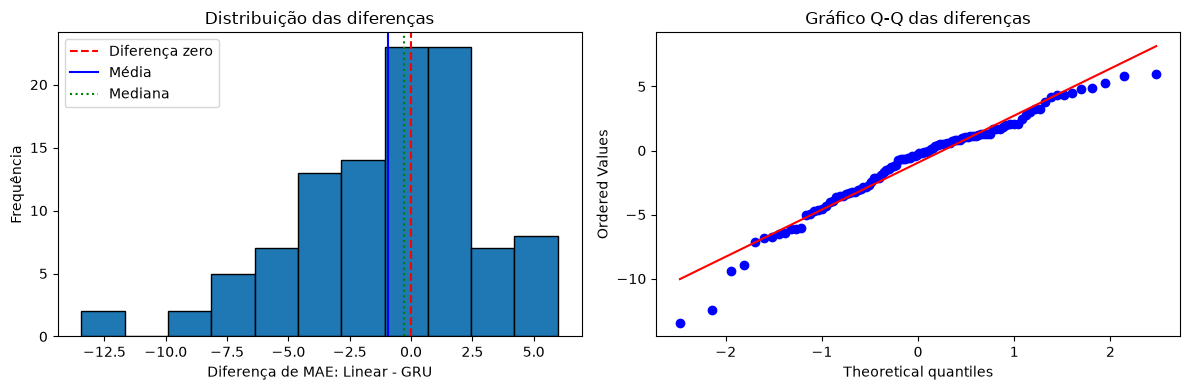

In [63]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    diferencas_mae,
    bins="auto",
    edgecolor="black"
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--",
    label="Diferença zero"
)

axes[0].axvline(
    diferencas_mae.mean(),
    color="blue",
    linestyle="-",
    label="Média"
)

axes[0].axvline(
    np.median(diferencas_mae),
    color="green",
    linestyle=":",
    label="Mediana"
)

axes[0].set_xlabel(
    "Diferença de MAE: Linear - GRU"
)

axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das diferenças")
axes[0].legend()

stats.probplot(
    diferencas_mae,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Gráfico Q-Q das diferenças"
)

plt.tight_layout()
plt.show()

In [64]:
n_linear_melhor = np.sum(
    diferencas_mae < 0
)

n_gru_melhor = np.sum(
    diferencas_mae > 0
)

n_empates = np.sum(
    np.isclose(diferencas_mae, 0)
)

print(
    f"Linear com menor MAE: {n_linear_melhor}"
)

print(
    f"GRU com menor MAE: {n_gru_melhor}"
)

print(
    f"Empates aproximados: {n_empates}"
)

Linear com menor MAE: 57
GRU com menor MAE: 47
Empates aproximados: 0


# Salvando os modelos

In [65]:
from pathlib import Path
from datetime import datetime
import gc

In [66]:
PASTA_MODELOS = Path("modelos_salvos")
PASTA_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

In [67]:
data_hora_execucao = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

print(
    "Identificação da execução:",
    data_hora_execucao
)

Identificação da execução: 2026-09-14_15-35-55


In [68]:
def salvar_checkpoint(
    modelo,
    nome_modelo,
    semente,
    tau,
    media_treino,
    desvio_treino,
    data_hora_execucao,
    pasta_modelos,
    hiperparametros=None,
    historico=None
):
    pasta_modelos = Path(pasta_modelos)

    pasta_modelos.mkdir(
        parents=True,
        exist_ok=True
    )

    nome_arquivo = (
        f"{nome_modelo.lower()}_"
        f"semente-{semente}_"
        f"{data_hora_execucao}.pth"
    )

    caminho = pasta_modelos / nome_arquivo

    checkpoint = {
        "nome_modelo": nome_modelo,
        "semente": int(semente),
        "tau": int(tau),
        "media_treino": float(media_treino),
        "desvio_treino": float(desvio_treino),
        "data_hora_execucao": data_hora_execucao,
        "hiperparametros": (
            hiperparametros
            if hiperparametros is not None
            else {}
        ),
        "historico": historico,
        "model_state_dict": {
            nome: tensor.detach().cpu()
            for nome, tensor
            in modelo.state_dict().items()
        }
    }

    torch.save(
        checkpoint,
        caminho
    )

    print(
        f"Modelo salvo em: {caminho}"
    )

    return caminho

In [69]:
hiperparametros_linear = {
    "arquitetura": "nn.Linear",
    "entrada": tau,
    "saida": 1,
    "lr": 0.001,
    "max_epocas": 200,
    "paciencia": 20,
    "batch_size": 32
}

hiperparametros_gru = {
    "arquitetura": "GRURegressor",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "saida": 1,
    "lr": 0.001,
    "max_epocas": 200,
    "paciencia": 20,
    "batch_size": 32
}

In [70]:
caminhos_modelos = {
    "Linear": [],
    "GRU": []
}

for nome_modelo in ["Linear", "GRU"]:

    for i, modelo in enumerate(
        modelos_treinados[nome_modelo]
    ):
        semente = SEMENTES[i]

        if nome_modelo == "Linear":
            hiperparametros = (
                hiperparametros_linear
            )
        else:
            hiperparametros = (
                hiperparametros_gru
            )

        caminho = salvar_checkpoint(
            modelo=modelo,
            nome_modelo=nome_modelo,
            semente=semente,
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            data_hora_execucao=data_hora_execucao,
            pasta_modelos=PASTA_MODELOS,
            hiperparametros=hiperparametros,
            historico=historicos[
                nome_modelo
            ][i]
        )

        caminhos_modelos[
            nome_modelo
        ].append(caminho)

Modelo salvo em: modelos_salvos\linear_semente-10_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\linear_semente-20_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\linear_semente-30_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\linear_semente-40_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\linear_semente-50_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\gru_semente-10_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\gru_semente-20_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\gru_semente-30_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\gru_semente-40_2026-09-14_15-35-55.pth
Modelo salvo em: modelos_salvos\gru_semente-50_2026-09-14_15-35-55.pth


In [71]:
for nome_modelo in modelos_treinados:
    for modelo in modelos_treinados[
        nome_modelo
    ]:
        modelo.to("cpu")

In [72]:
modelos_treinados.clear()

del modelos_treinados

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [73]:
variaveis_modelos = [
    "modelo",
    "modelo_linear",
    "modelo_gru"
]

for nome_variavel in variaveis_modelos:
    if nome_variavel in globals():
        del globals()[nome_variavel]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [74]:
if torch.cuda.is_available():
    print(
        "Memória alocada:",
        torch.cuda.memory_allocated()
        / 1024 ** 2,
        "MB"
    )

    print(
        "Memória reservada:",
        torch.cuda.memory_reserved()
        / 1024 ** 2,
        "MB"
    )

Memória alocada: 16.93310546875 MB
Memória reservada: 22.0 MB


In [75]:
def carregar_checkpoint(
    caminho,
    device=None
):
    caminho = Path(caminho)

    if device is None:
        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )

    nome_modelo = checkpoint["nome_modelo"]
    tau_checkpoint = checkpoint["tau"]
    hiperparametros = checkpoint.get(
        "hiperparametros",
        {}
    )

    if nome_modelo == "Linear":
        modelo = nn.Linear(
            tau_checkpoint,
            1
        )

    elif nome_modelo == "GRU":
        modelo = GRURegressor(
            hidden_size=hiperparametros.get(
                "hidden_size",
                64
            ),
            num_layers=hiperparametros.get(
                "num_layers",
                2
            ),
            dropout=hiperparametros.get(
                "dropout",
                0.2
            )
        )

    else:
        raise ValueError(
            f"Tipo de modelo desconhecido: "
            f"{nome_modelo}"
        )

    modelo.load_state_dict(
        checkpoint["model_state_dict"]
    )

    modelo = modelo.to(device)
    modelo.eval()

    metadados = {
        chave: valor
        for chave, valor
        in checkpoint.items()
        if chave != "model_state_dict"
    }

    print(
        f"Modelo carregado: {nome_modelo}"
    )

    print(
        f"Semente: {checkpoint['semente']}"
    )

    print(
        f"Data e hora: "
        f"{checkpoint['data_hora_execucao']}"
    )

    print(
        f"Dispositivo: {device}"
    )

    return modelo, metadados

In [76]:
device_inferencia = torch.device("cpu")

modelo_linear, meta_linear = (
    carregar_checkpoint(
        caminho=(
            "modelos_salvos/"
            "linear_semente-10_"
            "2026-09-14_15-20-35.pth"
        ),
        device=device_inferencia
    )
)

FileNotFoundError: [Errno 2] No such file or directory: 'modelos_salvos\\linear_semente-10_2026-09-14_15-20-35.pth'

In [77]:
modelo_gru, meta_gru = (
    carregar_checkpoint(
        caminho=(
            "modelos_salvos/"
            "gru_semente-10_"
            "2026-09-14_15-20-35.pth"
        ),
        device=device_inferencia
    )
)

FileNotFoundError: [Errno 2] No such file or directory: 'modelos_salvos\\gru_semente-10_2026-09-14_15-20-35.pth'

In [78]:
def localizar_modelo_mais_recente(
    pasta,
    tipo_modelo,
    semente=None
):
    pasta = Path(pasta)

    padrao = f"{tipo_modelo.lower()}_"

    if semente is not None:
        padrao += f"semente-{semente}_"

    padrao += "*.pth"

    arquivos = list(
     *  pasta.glob(padrao)
    )

    if*not arquivos:
        raise FileNo*FoundError(
            f"Nenhum m*delo encontrado com "
            *"o padrão: {padrao}"
        )

  * return max(
        arquivos,
   *    key=lambda arquivo: arquivo.st*t().st_mtime
    )

IndentationError: unindent does not match any outer indentation level (<string>, line 25)